In [3]:
import pandas as pd

df = pd.read_json('daikibo-telemetry-data.json')

df.head()

,deviceID,deviceType,timestamp,location,data
0,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:00:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 27}"
1,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:10:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 27}"
2,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:20:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 26}"
3,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:30:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 24}"
4,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:40:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 27}"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160704 entries, 0 to 160703
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   deviceID    160704 non-null  object        
 1   deviceType  160704 non-null  object        
 2   timestamp   160704 non-null  datetime64[ns]
 3   location    160704 non-null  object        
 4   data        160704 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 6.1+ MB


In [8]:
df.shape

(160704, 5)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_json("daikibo-telemetry-data.json")

In [13]:
print(df.columns)

Index(['deviceID', 'deviceType', 'timestamp', 'location', 'data'], dtype='object')


In [18]:
#Give value 10 for every unhealthy status
df["status"] = df["data"].apply(lambda x: x["status"])

In [19]:
df["Unhealthy"] = df["status"].apply(
    lambda x: 10 if x == "unhealthy" else 0
)

In [20]:
df[["status", "Unhealthy"]].head()

,status,Unhealthy
0,healthy,0
1,healthy,0
2,healthy,0
3,healthy,0
4,healthy,0


In [24]:
df["factory"] = df["location"].apply(lambda x: x["factory"])

In [25]:
factory_downtime = df.groupby("factory")["Unhealthy"].sum()

print(factory_downtime)

factory
daikibo-berlin            20
daikibo-factory-meiyo    110
daikibo-factory-seiko    480
daikibo-shenzhen         420
Name: Unhealthy, dtype: int64


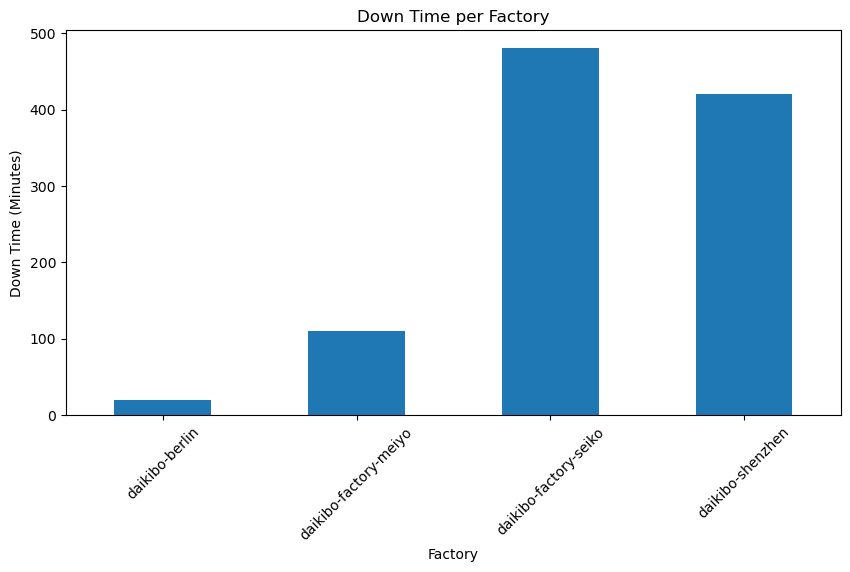

In [26]:
plt.figure(figsize=(10,5))

factory_downtime.plot(kind='bar')

plt.title("Down Time per Factory")
plt.xlabel("Factory")
plt.ylabel("Down Time (Minutes)")

plt.xticks(rotation=45)
plt.show()

In [27]:
print(df.columns)

Index(['deviceID', 'deviceType', 'timestamp', 'location', 'data', 'status',
       'Unhealthy', 'factory'],
      dtype='object')


In [29]:
device_downtime = df.groupby("deviceType")["Unhealthy"].sum()

print(device_downtime)

deviceType
AirWrench           0
CNC                10
ConveyorBelt       10
Furnace            20
HeavyDutyDrill     70
LaserCutter       430
LaserWelder       480
MetalPress          0
SpotWelder         10
Name: Unhealthy, dtype: int64


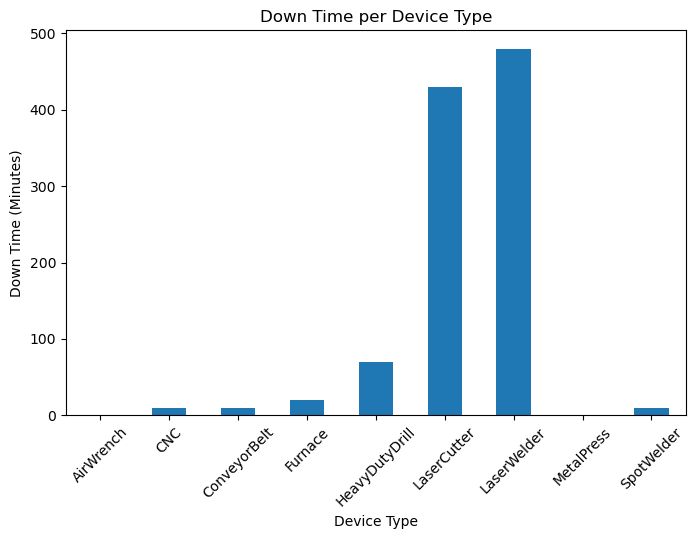

In [30]:
plt.figure(figsize=(8,5))

device_downtime.plot(kind='bar')

plt.title("Down Time per Device Type")
plt.xlabel("Device Type")
plt.ylabel("Down Time (Minutes)")

plt.xticks(rotation=45)
plt.show()

In [31]:
max_factory = factory_downtime.idxmax()
max_value = factory_downtime.max()

print("Factory with highest downtime:", max_factory)
print("Downtime:", max_value)

Factory with highest downtime: daikibo-factory-seiko
Downtime: 480


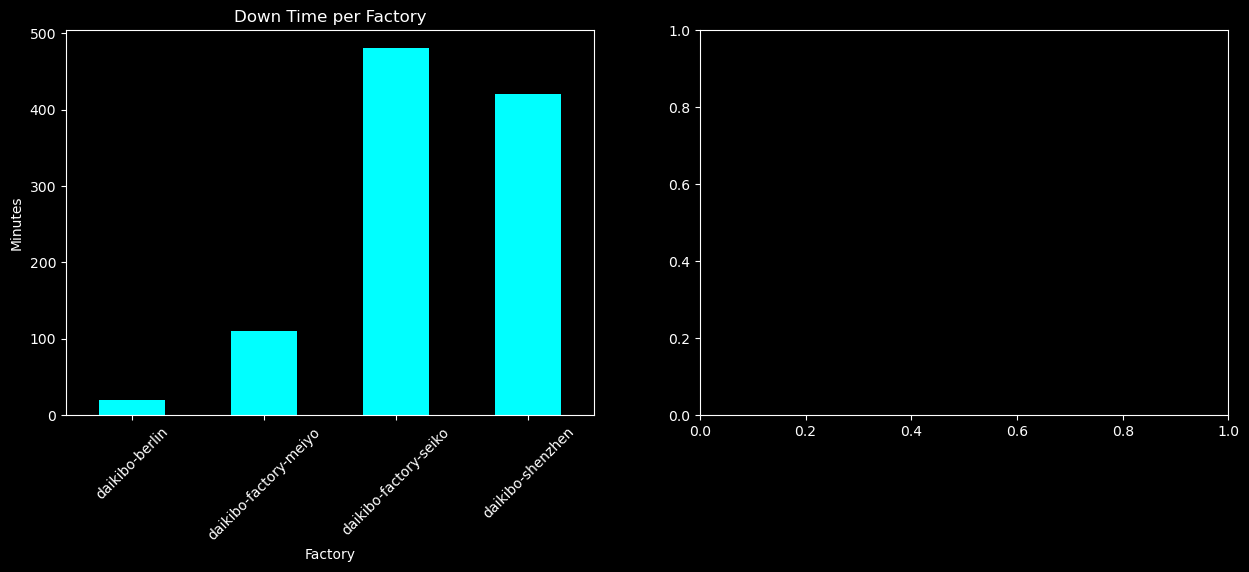

In [36]:
# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Set background color
fig.patch.set_facecolor('black')

for ax in axes:
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# Chart 1
factory_downtime.plot(
    kind='bar',
    ax=axes[0],
    color='cyan'   # Bar color
)

axes[0].set_title("Down Time per Factory")
axes[0].set_xlabel("Factory")
axes[0].set_ylabel("Minutes")
axes[0].tick_params(axis='x', rotation=45)


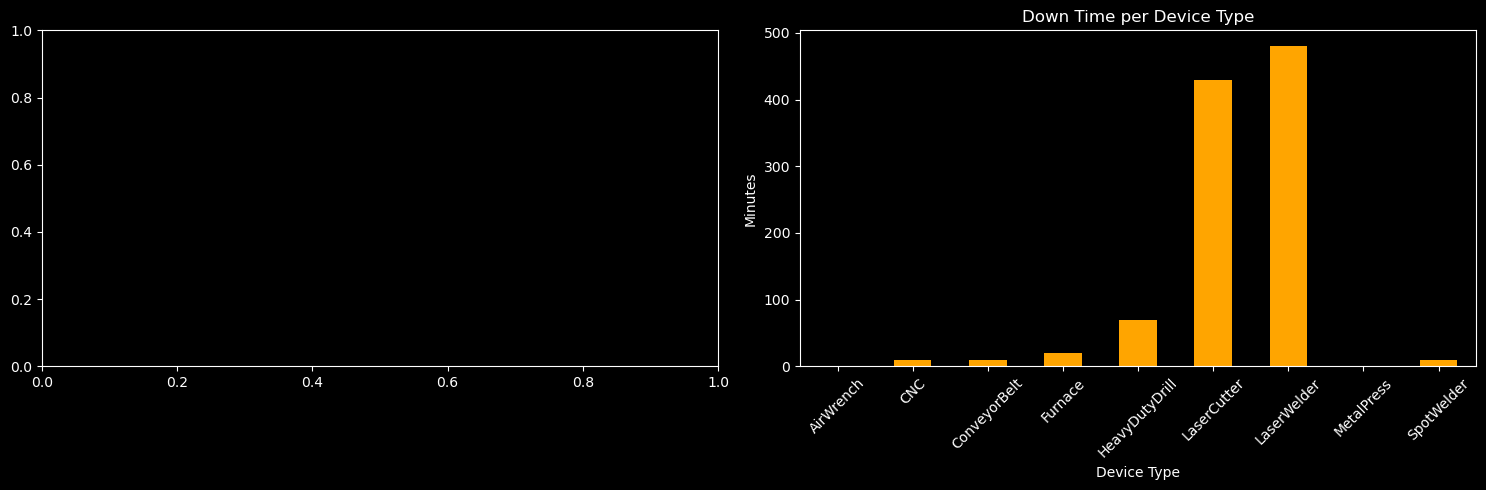

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Set background color
fig.patch.set_facecolor('black')

for ax in axes:
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')


# Chart 2
device_downtime.plot(
    kind='bar',
    ax=axes[1],
    color='orange'   # Bar color
)

axes[1].set_title("Down Time per Device Type")
axes[1].set_xlabel("Device Type")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

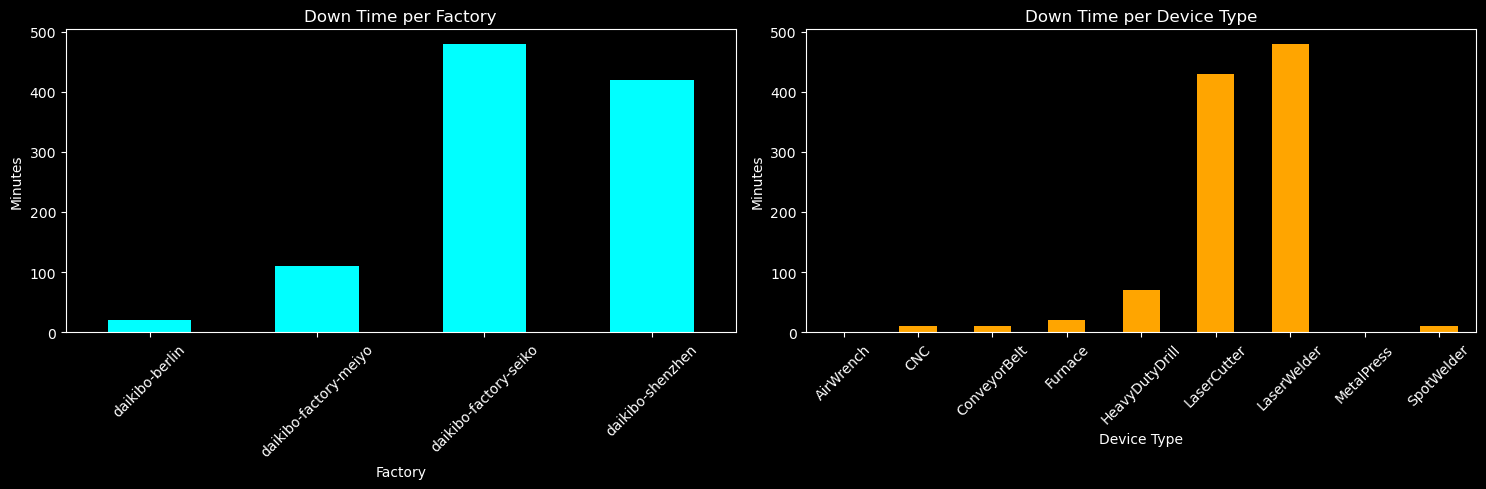

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Set background color
fig.patch.set_facecolor('black')

for ax in axes:
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# Chart 1
factory_downtime.plot(
    kind='bar',
    ax=axes[0],
    color='cyan'   # Bar color
)

axes[0].set_title("Down Time per Factory")
axes[0].set_xlabel("Factory")
axes[0].set_ylabel("Minutes")
axes[0].tick_params(axis='x', rotation=45)

# Chart 2
device_downtime.plot(
    kind='bar',
    ax=axes[1],
    color='orange'   # Bar color
)

axes[1].set_title("Down Time per Device Type")
axes[1].set_xlabel("Device Type")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()